# Module 1: Perceptron — Problem 1
**Course:** CSE 4204 — Sessional based on CSE 4203  
**Topic:** Calculate the weighted sum `z` and output `y` using eight activation functions.

> The provided lab-manual page lists the activation functions and shows the perceptron structure, but it does not specify numerical values for `x1`, `x2`, `w1`, `w2`, or `b`. The values below are editable example inputs. Replace them with values given by your instructor if applicable.

## Perceptron equation
\[
z = x_1w_1 + x_2w_2 + b
\]
The activation function transforms `z` into output `y = f(z)`.


## 1. Import required libraries
We use NumPy for numerical calculations and Matplotlib to visualize the activation functions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 2. Define inputs, weights, and bias
Edit these values to match your assigned problem. The example gives `z = 0.65`.


In [2]:
# Example values (replace if your question provides different values)
x1 = 1.0
x2 = 0.5
w1 = 0.7
w2 = -0.3
b = 0.1

z = x1 * w1 + x2 * w2 + b

print(f"x1 = {x1}, x2 = {x2}")
print(f"w1 = {w1}, w2 = {w2}, bias = {b}")
print(f"z = x1*w1 + x2*w2 + b = {z:.4f}")


x1 = 1.0, x2 = 0.5
w1 = 0.7, w2 = -0.3, bias = 0.1
z = x1*w1 + x2*w2 + b = 0.6500


## 3. Implement the activation functions

1. **Binary step:** returns 1 when `z >= 0`, otherwise 0.
2. **Linear:** returns `z` (identity activation).
3. **Sigmoid:** \(1/(1+e^{-z})\).
4. **Tanh:** hyperbolic tangent.
5. **ReLU:** \(\max(0,z)\).
6. **Leaky ReLU:** returns `z` if positive, otherwise `alpha*z`.
7. **Parametric ReLU (PReLU):** same piecewise form, with a learnable alpha in a trained model; here alpha is set manually for demonstration.
8. **Softmax:** converts a vector of logits into probabilities. Applied to one scalar alone, softmax is always 1, so a two-class example is also shown below.


In [3]:
def binary_step(z):
    return 1 if z >= 0 else 0

def linear(z):
    return z

def sigmoid(z):
    # Numerically stable scalar sigmoid
    if z >= 0:
        return 1 / (1 + np.exp(-z))
    exp_z = np.exp(z)
    return exp_z / (1 + exp_z)

def tanh_activation(z):
    return np.tanh(z)

def relu(z):
    return max(0, z)

def leaky_relu(z, alpha=0.01):
    return z if z >= 0 else alpha * z

def prelu(z, alpha=0.1):
    # alpha is fixed here; in a neural network PReLU's alpha is learned
    return z if z >= 0 else alpha * z

def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    shifted = logits - np.max(logits)  # numerical stability
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values)


## 4. Calculate y for each activation function
The table below reports the result for the same weighted sum `z`.


In [4]:
alpha_leaky = 0.01
alpha_prelu = 0.1

results = [
    ("Binary Step", binary_step(z)),
    ("Linear", linear(z)),
    ("Sigmoid", sigmoid(z)),
    ("Tanh", tanh_activation(z)),
    ("ReLU", relu(z)),
    (f"Leaky ReLU (alpha={alpha_leaky})", leaky_relu(z, alpha_leaky)),
    (f"PReLU (alpha={alpha_prelu})", prelu(z, alpha_prelu)),
    ("Softmax (single scalar)", softmax([z])[0]),
]

print(f"Weighted sum z = {z:.4f}\n")
for name, y in results:
    print(f"{name:32s} y = {float(y):.6f}")


Weighted sum z = 0.6500

Binary Step                      y = 1.000000
Linear                           y = 0.650000
Sigmoid                          y = 0.657010
Tanh                             y = 0.571670
ReLU                             y = 0.650000
Leaky ReLU (alpha=0.01)          y = 0.650000
PReLU (alpha=0.1)                y = 0.650000
Softmax (single scalar)          y = 1.000000


## 5. Softmax clarification for a two-class output
A perceptron with one scalar output has `softmax([z]) = [1.0]`, which is not informative for classification. For a two-class illustration, use logits `[z, 0]`; the two probabilities sum to 1. These are illustrative logits, not additional values specified in the manual.


In [5]:
two_class_logits = [z, 0.0]
two_class_probabilities = softmax(two_class_logits)

print("Logits:", two_class_logits)
print("Softmax probabilities:", two_class_probabilities)
print("Sum of probabilities:", two_class_probabilities.sum())


Logits: [0.6499999999999999, 0.0]
Softmax probabilities: [0.65701046 0.34298954]
Sum of probabilities: 1.0


## 6. Visualize the activation functions
The vertical marker indicates the calculated `z` for the selected input values.


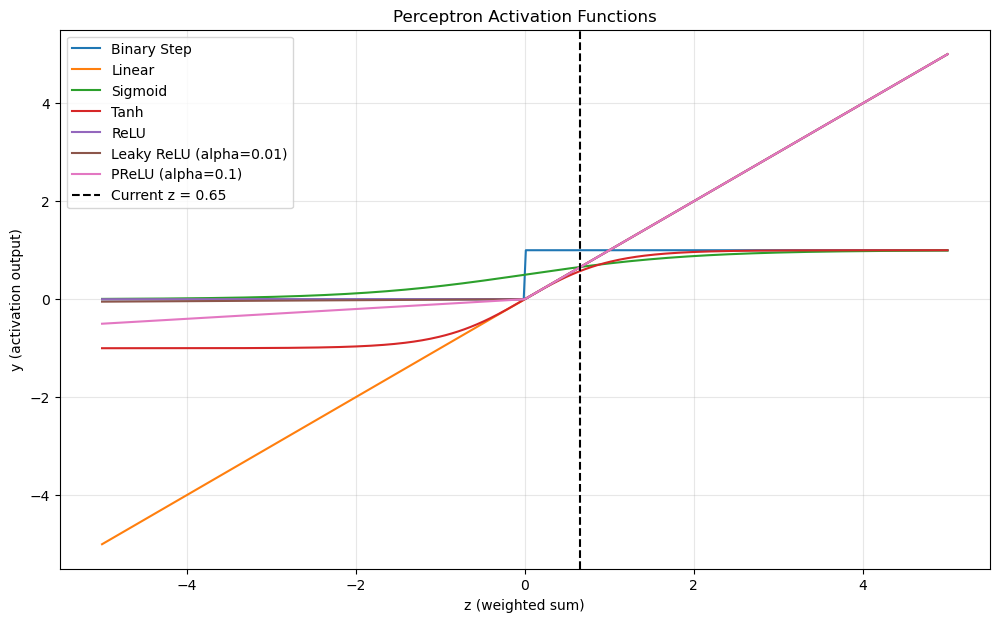

In [6]:
z_values = np.linspace(-5, 5, 400)
alpha = 0.1

plt.figure(figsize=(12, 7))
plt.plot(z_values, [binary_step(v) for v in z_values], label="Binary Step")
plt.plot(z_values, z_values, label="Linear")
plt.plot(z_values, 1 / (1 + np.exp(-z_values)), label="Sigmoid")
plt.plot(z_values, np.tanh(z_values), label="Tanh")
plt.plot(z_values, np.maximum(0, z_values), label="ReLU")
plt.plot(z_values, np.where(z_values >= 0, z_values, 0.01*z_values), label="Leaky ReLU (alpha=0.01)")
plt.plot(z_values, np.where(z_values >= 0, z_values, alpha*z_values), label="PReLU (alpha=0.1)")
plt.axvline(z, color="black", linestyle="--", label=f"Current z = {z:.2f}")
plt.xlabel("z (weighted sum)")
plt.ylabel("y (activation output)")
plt.title("Perceptron Activation Functions")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 7. Conclusion
First calculate the weighted sum `z = x1*w1 + x2*w2 + b`. Then apply each activation function to obtain its output `y`. Different activation functions can produce different outputs from the same `z`. For softmax, use a vector of logits when the model has multiple classes.
